<a href="https://colab.research.google.com/github/Yaroslavwvw/image_processing/blob/main/%D0%9F%D0%A05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Эффективная обработка растровых и векторных данных в XARRAY и RIOXARRAY**

## **Раздел 1. Эффективная работа с наборами векторных данных в библиотеке XARRAY**

In [ ]:
%%capture
!pip install xarray pooch cftime

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Настройка сохранения атрибутов и отображения данных
xr.set_options(keep_attrs=True, display_expand_data=False)
np.set_printoptions(threshold=10, edgeitems=2)

---

### **Задание 1. Изучение нового набора данных**

1. Загрузите обучающий набор данных Xarray `rasm`.


- Xarray предоставляет встроенный доступ к нескольким [обучающим наборам данных](https://docs.xarray.dev/en/latest/generated/xarray.tutorial.open_dataset.html), которые мы можем загрузить с помощью `xr.tutorial.open_dataset`.

In [ ]:
ds = xr.tutorial.open_dataset("rasm")
ds

<xarray.Dataset> Size: 17MB
Dimensions:  (time: 36, y: 205, x: 275)
Coordinates:
  * time     (time) object 288B 1980-09-16 12:00:00 ... 1983-08-17 00:00:00
    xc       (y, x) float64 451kB ...
    yc       (y, x) float64 451kB ...
Dimensions without coordinates: y, x
Data variables:
    Tair     (time, y, x) float64 16MB ...
Attributes:
    title:                     /workspace/jhamman/processed/R1002RBRxaaa01a/l...
    institution:               U.W.
    source:                    RACM R1002RBRxaaa01a
    output_frequency:          daily
    output_mode:               averaged
    convention:                CF-1.4
    references:                Based on the initial model of Liang et al., 19...
    comment:                   Output from the Variable Infiltration Capacity...
    nco_openmp_thread_number:  1
    NCO:                       netCDF Operators version 4.7.9 (Homepage = htt...
    history:                   Fri Aug  7 17:57:38 2020: ncatted -a bounds,,d...

2. Изучите объект `Dataset` и перечислите все переменные и измерения.


In [ ]:
print("\nВсе переменные Dataset:")
print(ds.variables)

print("\nПеременные данных (data_vars):")
print(list(ds.data_vars))

print("\nКоординаты (coords):")
print(list(ds.coords))

print("\nИзмерения и их длины:")
print(ds.sizes)


Все переменные Dataset:
Frozen({'Tair': <xarray.Variable (time: 36, y: 205, x: 275)> Size: 16MB
[2029500 values with dtype=float64]
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous, 'time': <xarray.IndexVariable 'time' (time: 36)> Size: 288B
array([cftime.DatetimeNoLeap(1980, 9, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1980, 10, 17, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1980, 11, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1980, 12, 17, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1981, 1, 17, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1981, 2, 15, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1981, 3, 17, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1981, 4, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1981, 5, 17, 0, 0, 0, 0, ha

3. Выберите переменную `Tair` (температура воздуха).


In [ ]:
Tair = ds.Tair
Tair

<xarray.DataArray 'Tair' (time: 36, y: 205, x: 275)> Size: 16MB
array([[[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [      nan,       nan, ..., 26.802619, 27.086035],
        [      nan,       nan, ..., 26.564739, 26.730649]],

       [[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [      nan,       nan, ..., 24.29624 , 24.614224],
        [      nan,       nan, ..., 24.299677, 24.454399]],

       ...,

       [[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [      nan,       nan, ..., 27.311049, 27.673872],
        [      nan,       nan, ..., 27.008894, 27.23018 ]],

       [[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [      nan,       nan, ..., 28.422736, 28.687212],
        [      nan,       nan, ..., 28.185955, 28.20753 ]]])
Coordinates:
  * time     (time) object 288B 1980-09-16 12:00:00 ... 1983-08-17 00:00:00
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

4. Выведите атрибуты, измерения и координаты `Tair`.

In [ ]:
print("Атрибуты Tair:")
print(Tair.attrs)

print("\nИзмерения Tair:")
print(Tair.dims)

print("\nРазмеры измерений Tair:")
print(Tair.sizes)

print("\nКоординаты Tair:")
print(Tair.coords)

Атрибуты Tair:
{'units': 'C', 'long_name': 'Surface air temperature', 'type_preferred': 'double', 'time_rep': 'instantaneous'}

Измерения Tair:
('time', 'y', 'x')

Размеры измерений Tair:
Frozen({'time': 36, 'y': 205, 'x': 275})

Координаты Tair:
Coordinates:
  * time     (time) object 288B 1980-09-16 12:00:00 ... 1983-08-17 00:00:00
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51


---

### **Задание 2. Выбор данных и индексирование**

1. Выберите подмножество данных `Tair` для первой доступной даты `1980-09-16` и широты `70.0` долготы `100.0`.


In [ ]:
Tair_0 = Tair.isel(time=0)
lat = ds["yc"]
lon = ds["xc"]

target_lat = 70.0
target_lon = 100.0

dist2 = (lat - target_lat) ** 2 + (lon - target_lon) ** 2

iy, ix = np.unravel_index(dist2.argmin(), dist2.shape)

print("Фактическая широта/долгота этой точки:",
      float(lat[iy, ix].values),
      float(lon[iy, ix].values))

sub_Tair = Tair.isel(time=0, y=iy, x=ix)
print(sub_Tair)

Фактическая широта/долгота этой точки: 70.16052954683822 100.3583518837136
<xarray.DataArray 'Tair' ()> Size: 8B
[1 values with dtype=float64]
Coordinates:
    time     object 8B 1980-09-16 12:00:00
    xc       float64 8B 100.4
    yc       float64 8B 70.16
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous


2. Сформируйте временной срез для всего диапазона широт между январем и мартом 1981 года.


In [ ]:
time_slice = slice("1981-01-01", "1981-03-31")
Tair_slice = Tair.sel(time=time_slice)

Tair_slice

<xarray.DataArray 'Tair' (time: 3, y: 205, x: 275)> Size: 1MB
array([[[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [      nan,       nan, ..., 11.332398, 11.80017 ],
        [      nan,       nan, ..., 11.917968, 12.335864]],

       [[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [      nan,       nan, ..., 12.020273, 12.171659],
        [      nan,       nan, ..., 11.958136, 12.366265]],

       [[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [      nan,       nan, ..., 16.600722, 16.979505],
        [      nan,       nan, ..., 16.848232, 16.901854]]])
Coordinates:
  * time     (time) object 24B 1981-01-17 00:00:00 ... 1981-03-17 00:00:00
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

3. Визуализируйте выбранный временной срез в виде линейного графика.

/tmp/ipython-input-937301802.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  Tair_slice["time"] = Tair_slice.indexes["time"].to_datetimeindex()
/tmp/ipython-input-937301802.py:1: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  Tair_slice["time"] = Tair_slice.indexes["time"].to_datetimeindex()


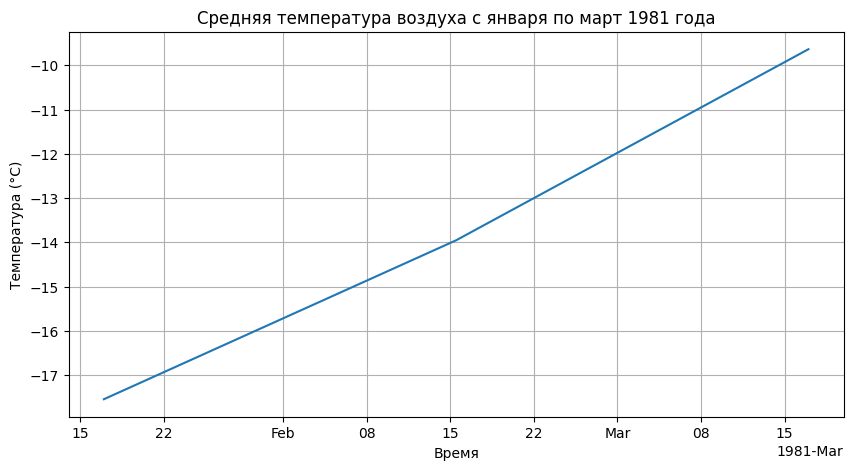

In [ ]:
Tair_slice["time"] = Tair_slice.indexes["time"].to_datetimeindex()
Tair_mean = Tair_slice.mean(dim=["y", "x"])

plt.figure(figsize=(10,5))
Tair_mean.plot()
plt.title("Средняя температура воздуха с января по март 1981 года")
plt.ylabel("Температура (°C)")
plt.xlabel("Время")
plt.grid(True)
plt.show()

---

### **Задание 3. Выполнение арифметических операций**

1. Вычислите среднее значение данных `Tair` по измерению `time`.


In [ ]:
Tair_time_mean = Tair.mean(dim="time")

Tair_time_mean

<xarray.DataArray 'Tair' (y: 205, x: 275)> Size: 451kB
nan nan nan nan nan nan nan nan ... 21.21 21.34 21.99 21.9 20.86 20.52 20.69
Coordinates:
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

2. Вычтите вычисленное среднее из исходного набора данных `Tair`, чтобы получить аномалии температуры.


In [ ]:
Tair_anomalies = Tair - Tair_mean

Tair_anomalies

<xarray.DataArray 'Tair' (time: 36, y: 205, x: 275)> Size: 16MB
nan nan nan nan nan nan nan nan ... 7.755 7.776 7.85 7.644 7.9 7.801 7.671 7.519
Coordinates:
  * time     (time) object 288B 1980-09-16 12:00:00 ... 1983-08-17 00:00:00
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

3. Визуализируйте отдельно график средней температуры и график аномалий.

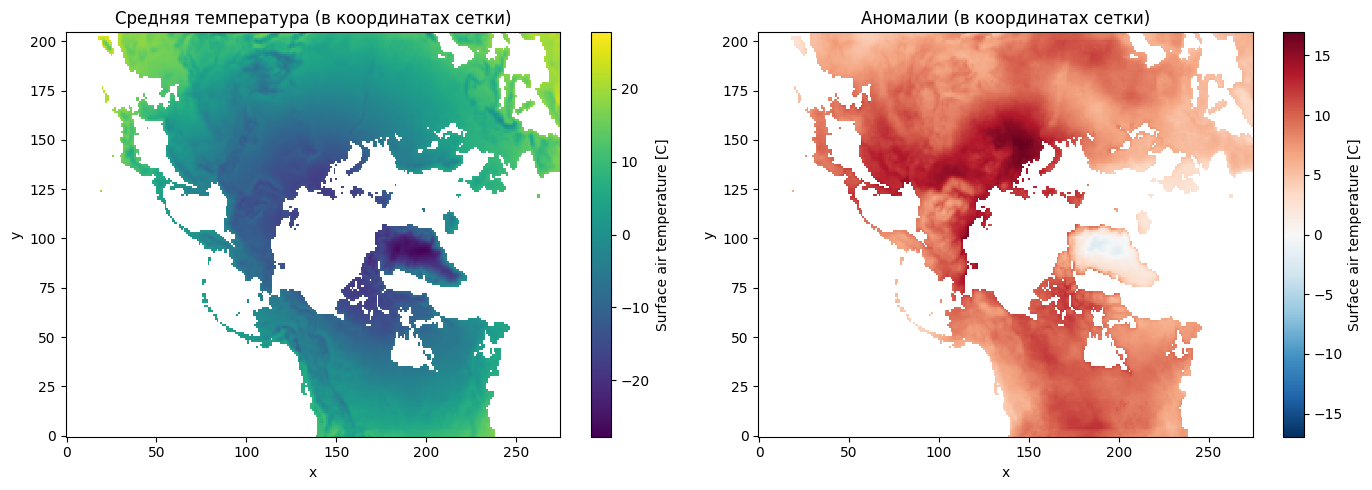

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 5))

Tair_mean.plot.pcolormesh(ax=axes[0], x="x", y="y", cmap="viridis", add_colorbar=True)
axes[0].set_title("Средняя температура (в координатах сетки)")

Tair_anomalies.isel(time=0).plot.pcolormesh(ax=axes[1], x="x", y="y", cmap="RdBu_r", add_colorbar=True)
axes[1].set_title("Аномалии (в координатах сетки)")

plt.tight_layout()
plt.show()


---

### **Задание 4. GroupBy и агрегация**

1. Используйте `groupby` для расчета среднесезонной температуры (`Tair`).


In [ ]:
seasonal_mean = Tair.groupby("time.season").mean(dim="time")

seasonal_mean

<xarray.DataArray 'Tair' (season: 4, y: 205, x: 275)> Size: 2MB
nan nan nan nan nan nan nan nan ... 22.71 22.75 23.34 23.13 22.06 21.72 21.94
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

2. Используйте `resample` для расчета среднемесячной температуры за 1980 год.


In [ ]:
Tair_1980 = Tair.sel(time="1980")
Tair_monthly = Tair_1980.resample(time="1MS").mean()

Tair_monthly

<xarray.DataArray 'Tair' (time: 4, y: 205, x: 275)> Size: 2MB
nan nan nan nan nan nan nan nan ... 13.2 13.05 14.01 13.4 11.94 11.72 12.01
Coordinates:
  * time     (time) object 32B 1980-09-01 00:00:00 ... 1980-12-01 00:00:00
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

3. Постройте сезонное среднее для каждого сезона и выведите среднемесячное значение.

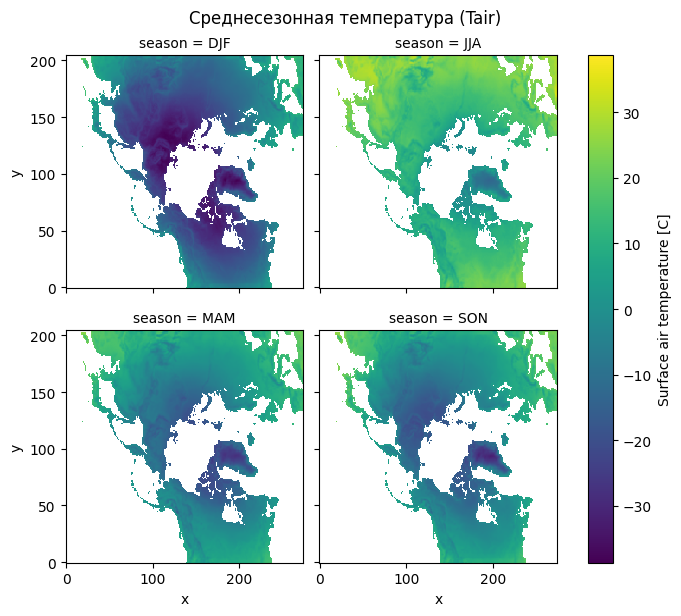

Среднемесячные значения за 1980 год (усредено по всему пространству):
                          Tair
time                          
1980-09-01 00:00:00   8.187292
1980-10-01 00:00:00  -0.701279
1980-11-01 00:00:00  -8.989001
1980-12-01 00:00:00 -13.331630

Объект DataArray (среднемесячные 1980):


<xarray.DataArray 'Tair' (time: 4, y: 205, x: 275)> Size: 2MB
nan nan nan nan nan nan nan nan ... 13.2 13.05 14.01 13.4 11.94 11.72 12.01
Coordinates:
  * time     (time) object 32B 1980-09-01 00:00:00 ... 1980-12-01 00:00:00
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

In [ ]:
seasonal_mean.plot.pcolormesh(
    col="season",
    col_wrap=2,
    x="x", y="y",
    cmap="viridis",
    add_colorbar=True
)
plt.suptitle("Среднесезонная температура (Tair)", y=1.02)
plt.show()

print("Среднемесячные значения за 1980 год (усредено по всему пространству):")
print(Tair_monthly.mean(dim=["x", "y"]).to_dataframe()[["Tair"]])

print("\nОбъект DataArray (среднемесячные 1980):")
Tair_monthly

---

### **Задание 5. Запись данных в netCDF**

1. Выберите аномалии температуры, рассчитанные в Упражнении 3.


In [ ]:
print("Аномалии температуры:")
Tair_anomalies

Аномалии температуры:


<xarray.DataArray 'Tair' (time: 36, y: 205, x: 275)> Size: 16MB
nan nan nan nan nan nan nan nan ... 7.755 7.776 7.85 7.644 7.9 7.801 7.671 7.519
Coordinates:
  * time     (time) object 288B 1980-09-16 12:00:00 ... 1983-08-17 00:00:00
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

2. Преобразуйте переменную `Tair` в `float32` для оптимизации размера файла.


In [ ]:
Tair_anomalies_f32 = Tair_anomalies.astype("float32")

print(Tair_anomalies_f32.dtype)
Tair_anomalies_f32

float32


<xarray.DataArray 'Tair' (time: 36, y: 205, x: 275)> Size: 8MB
nan nan nan nan nan nan nan nan ... 7.755 7.776 7.85 7.644 7.9 7.801 7.671 7.519
Coordinates:
  * time     (time) object 288B 1980-09-16 12:00:00 ... 1983-08-17 00:00:00
    xc       (y, x) float64 451kB 189.2 189.4 189.6 189.7 ... 17.4 17.15 16.91
    yc       (y, x) float64 451kB 16.53 16.78 17.02 17.27 ... 28.01 27.76 27.51
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

3. Запишите данные аномалий в новый файл netCDF с именем `tair_anomalies.nc`.


In [ ]:
Tair_anomalies_f32.to_netcdf("tair_anomalies.nc")

4. Загрузите данные обратно из файла и выведите его содержимое.

In [ ]:
loaded_anomalies = xr.open_dataarray("tair_anomalies.nc")

loaded_anomalies

<xarray.DataArray 'Tair' (time: 36, y: 205, x: 275)> Size: 8MB
[2029500 values with dtype=float32]
Coordinates:
  * time     (time) object 288B 1980-09-16 12:00:00 ... 1983-08-17 00:00:00
    xc       (y, x) float64 451kB ...
    yc       (y, x) float64 451kB ...
Dimensions without coordinates: y, x
Attributes:
    units:           C
    long_name:       Surface air temperature
    type_preferred:  double
    time_rep:        instantaneous

---

## **Раздел 2. Эффективная работа с наборами векторных данных в библиотеке RIOXARRAY**

### **Используемый набор данных для выполнения заданий**

Для выполнения заданий мы будем использовать образец растрового набора данных GeoTIFF Ливии, который доступен по следующему URL:


- https://github.com/opengeos/datasets/releases/download/raster/Libya-2023-09-13_clip.tif

---

### **Задание 1. Загрузка и исследование растрового набора данных**

1. Используйте `rioxarray` для загрузки файла GeoTIFF.


In [ ]:
!pip install rioxarray

In [ ]:
import rioxarray

url = "https://github.com/opengeos/datasets/releases/download/raster/Libya-2023-09-13_clip.tif"
data = rioxarray.open_rasterio(url)
data

<xarray.DataArray (band: 4, y: 1722, x: 2807)> Size: 19MB
[19334616 values with dtype=uint8]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 14kB 3.628e+06 3.628e+06 ... 3.626e+06 3.626e+06
  * x            (x) float64 22kB 6.522e+05 6.522e+05 ... 6.55e+05 6.55e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_offset:          0.0

2. Изучите набор данных, выведя его размеры, координаты и атрибуты.


In [ ]:
print("\nРазмеры (Dims)")
print(data.dims)

print("\nКоординаты (Coords)")
print(data.coords)

print("\nАтрибуты (Attrs)")
print(data.attrs)


Размеры (Dims)
('band', 'y', 'x')

Координаты (Coords)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 14kB 3.628e+06 3.628e+06 ... 3.626e+06 3.626e+06
  * x            (x) float64 22kB 6.522e+05 6.522e+05 ... 6.55e+05 6.55e+05
    spatial_ref  int64 8B 0

Атрибуты (Attrs)
{'OVR_RESAMPLING_ALG': 'NEAREST', 'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0}


3. Проверьте и выведите CRS и аффинное преобразование набора данных.

In [ ]:
print("CRS набора данных:")
print(data.rio.crs)
print("\nАффинное преобразование (Transform):")
print(data.rio.transform())

CRS набора данных:
EPSG:32634

Аффинное преобразование (Transform):
| 1.00, 0.00, 652207.03|
| 0.00,-1.00, 3627663.88|
| 0.00, 0.00, 1.00|


---

### **Задание 2. Перепроецирование растра в новую CRS**

1. Перепроецируйте загруженный растровый набор данных из его исходной CRS в EPSG:4326 (WGS84).


In [ ]:
data_reprojected = data.rio.reproject("EPSG:4326")

print("Новая CRS:", data_reprojected.rio.crs)
data_reprojected

Новая CRS: EPSG:4326


<xarray.DataArray (band: 4, y: 1557, x: 2957)> Size: 18MB
255 255 255 255 255 255 255 255 255 255 ... 255 255 255 255 255 255 255 255 255
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 12kB 32.78 32.78 32.78 32.78 ... 32.76 32.76 32.76
  * x            (x) float64 24kB 22.62 22.62 22.62 22.62 ... 22.66 22.66 22.66
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_offset:          0.0
    _FillValue:          255

2. Выведите новую CRS и проверьте размеры и координаты перепроецированных данных.


In [ ]:
print(f"Новая CRS: {data_reprojected.rio.crs}")

print("\nРазмеры и координаты после перепроецирования:")
print(data_reprojected.sizes)
print(data_reprojected.coords)

Новая CRS: EPSG:4326

Размеры и координаты после перепроецирования:
Frozen({'band': 4, 'y': 1557, 'x': 2957})
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 12kB 32.78 32.78 32.78 32.78 ... 32.76 32.76 32.76
  * x            (x) float64 24kB 22.62 22.62 22.62 22.62 ... 22.66 22.66 22.66
    spatial_ref  int64 8B 0


3. Отобразите исходный и перепроецированный наборы данных для сравнения.

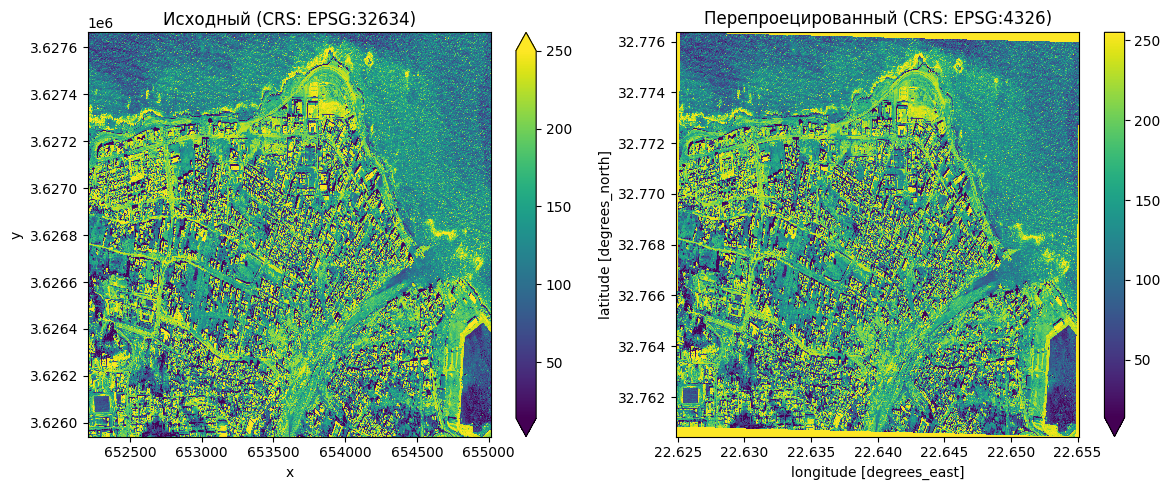

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

data.isel(band=0).plot(ax=axes[0], robust=True, cmap="viridis")
axes[0].set_title(f"Исходный (CRS: {data.rio.crs.to_string()})")

data_reprojected.isel(band=0).plot(ax=axes[1], robust=True, cmap="viridis")
axes[1].set_title(f"Перепроецированный (CRS: {data_reprojected.rio.crs.to_string()})")

plt.tight_layout()
plt.show()


---

### **Задание 3. Обрезка растра с использованием ограничивающего прямоугольника**

1. Определите ограничивающий прямоугольник (например, `xmin`, `ymin`, `xmax`, `ymax`), который охватывает территорию Ливии.


In [ ]:
bounds = data_reprojected.rio.bounds()
xmin = bounds[0] + 0.005
ymin = bounds[1] + 0.005
xmax = bounds[2] - 0.005
ymax = bounds[3] - 0.005
box = [xmin, ymin, xmax, ymax]

2. Обрежьте растровый набор данных, используя этот ограничивающий прямоугольник.


In [ ]:
clipped_data = data_reprojected.rio.clip_box(*box)

print("Размеры обрезанного растра:", clipped_data.rio.shape)
clipped_data


Размеры обрезанного растра: (581, 1981)


<xarray.DataArray (band: 4, y: 581, x: 1981)> Size: 5MB
29 19 48 68 106 153 143 113 19 40 31 ... 255 255 255 255 255 255 255 255 255 255
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 5kB 32.77 32.77 32.77 32.77 ... 32.77 32.77 32.77
  * x            (x) float64 16kB 22.63 22.63 22.63 22.63 ... 22.65 22.65 22.65
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_offset:          0.0
    _FillValue:          255

3. Отобразите обрезанные данные для визуализации результата.

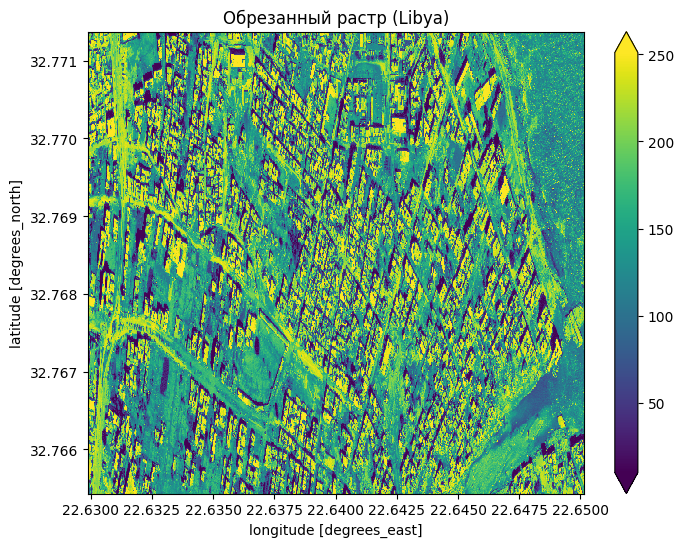

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

clipped_data.isel(band=0).plot(ax=ax, robust=True, cmap="viridis")

ax.set_title("Обрезанный растр (Libya)")
plt.show()

---

### **Задание 4. Маскирование растра с использованием векторного набора данных**

1. Загрузите файл GeoJSON по адресу https://github.com/opengeos/datasets/releases/download/raster/Derna_Libya.geojson, используя `geopandas`.


In [ ]:
!pip install geopandas

In [ ]:
import geopandas as gpd

url_geojson = "https://github.com/opengeos/datasets/releases/download/raster/Derna_Libya.geojson"
gdf = gpd.read_file(url_geojson)

print("Векторные данные загружены. Размер:", gdf.shape)
print(gdf.head())


Векторные данные загружены. Размер: (1, 1)
                                            geometry
0  POLYGON ((22.64334 32.76452, 22.64334 32.7686,...


2. Используйте GeoJSON для маскирования растрового набора данных, сохраняя только данные в пределах границ GeoJSON.


In [ ]:
masked_data = data_reprojected.rio.clip(gdf.geometry, drop=True)

print("Размеры после маскирования по GeoJSON:", masked_data.rio.shape)
masked_data


Размеры после маскирования по GeoJSON: (398, 896)


<xarray.DataArray (band: 4, y: 398, x: 896)> Size: 1MB
231 227 240 234 229 131 62 36 54 54 ... 255 255 255 255 255 255 255 255 255 255
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 3kB 32.77 32.77 32.77 32.77 ... 32.76 32.76 32.76
  * x            (x) float64 7kB 22.64 22.64 22.64 22.64 ... 22.65 22.65 22.65
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_offset:          0.0
    _FillValue:          255

3. Отобразите маскированные растровые данные.

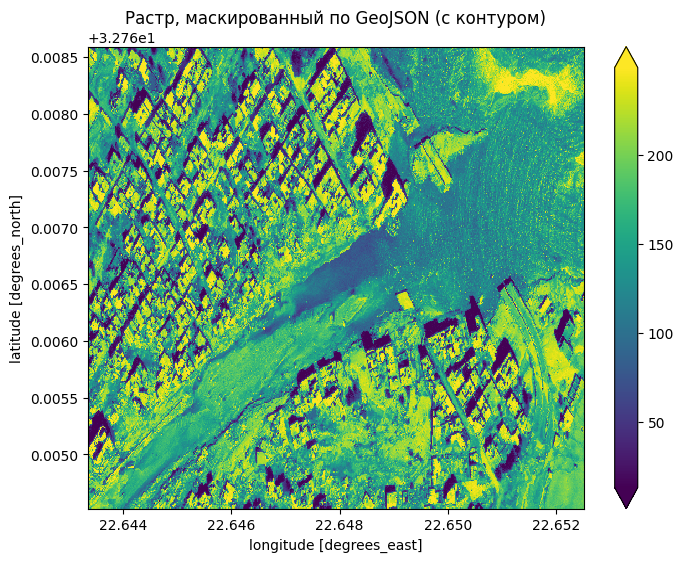

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

masked_data.isel(band=0).plot(ax=ax, robust=True, cmap="viridis")

ax.set_title("Растр, маскированный по GeoJSON (с контуром)")
plt.show()


---

### **Задание 5. Преобразование растра**

1. Выполните ресемплинг растрового набора данных до разрешения 3 м, используя метод усреднения.


In [ ]:
from rasterio.enums import Resampling

# 1. Определяем подходящую UTM зону (для Ливии/Дерны это 34N -> EPSG:32634)
utm_crs = "EPSG:32634"

# 2. Перепроецируем в UTM с одновременным изменением разрешения
# resolution=3 означает 3 метра (так как UTM в метрах)
resampled_data = data_reprojected.rio.reproject(
    dst_crs=utm_crs,
    resolution=3,
    resampling=Resampling.average
)

print("Новая CRS:", resampled_data.rio.crs)
print("Новое разрешение (в метрах):", resampled_data.rio.resolution())
print("Новые размеры:", resampled_data.rio.shape)

Новая CRS: EPSG:32634
Новое разрешение (в метрах): (3.0, -3.0)
Новые размеры: (603, 954)


2. Проверьте новые размеры и координаты после ресемплинга.


In [ ]:
print("Новые размеры (y, x):", resampled_data.rio.shape)

print("Разрешение (dx, dy):", resampled_data.rio.resolution())

print("\nКоординаты X (первые 5):", resampled_data.coords["x"].values[:5])
print("Координаты Y (первые 5):", resampled_data.coords["y"].values[:5])

resampled_data

Новые размеры (y, x): (603, 954)
Разрешение (dx, dy): (3.0, -3.0)

Координаты X (первые 5): [652182.09205371 652185.09205371 652188.09205371 652191.09205371
 652194.09205371]
Координаты Y (первые 5): [3627705.87474823 3627702.87474823 3627699.87474823 3627696.87474823
 3627693.87474823]


<xarray.DataArray (band: 4, y: 603, x: 954)> Size: 2MB
255 255 255 255 255 255 255 255 255 255 ... 255 255 255 255 255 255 255 255 255
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 5kB 3.628e+06 3.628e+06 ... 3.626e+06 3.626e+06
  * x            (x) float64 8kB 6.522e+05 6.522e+05 ... 6.55e+05 6.55e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_offset:          0.0
    _FillValue:          255

3. Сохраните ресемплированный растровый набор данных в новый файл GeoTIFF.

In [ ]:
output_filename = "resampled_libya_3m.tif"
resampled_data.rio.to_raster(output_filename)

Информация о сохраненном файле
CRS: EPSG:32634
Размеры: (603, 954)
Разрешение: (3.0, -3.0)
Границы: (652180.5920537133, 3625898.3747482304, 655042.5920537133, 3627707.3747482304)


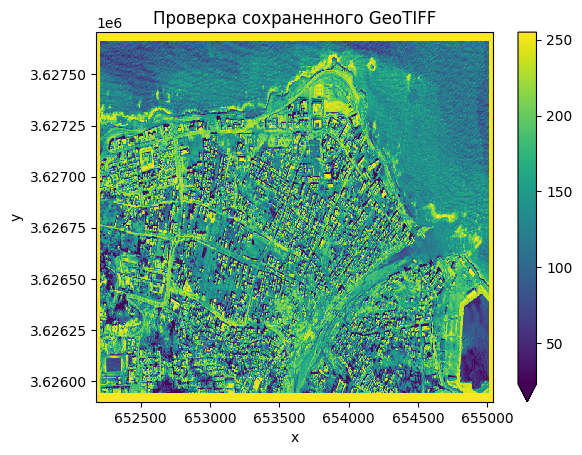

In [ ]:
check_data = rioxarray.open_rasterio("resampled_libya_3m.tif")

print("Информация о сохраненном файле")
print(f"CRS: {check_data.rio.crs}")
print(f"Размеры: {check_data.rio.shape}")
print(f"Разрешение: {check_data.rio.resolution()}")
print(f"Границы: {check_data.rio.bounds()}")

check_data.isel(band=0).plot(cmap="viridis", robust=True)
plt.title("Проверка сохраненного GeoTIFF")
plt.show()